<a href="https://colab.research.google.com/github/skandanyal/ML_Projects_in_Python/blob/main/Diabetic_Retinopathy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os

# Download latest version
DATASET_PATH = kagglehub.dataset_download("sovitrath/diabetic-retinopathy-224x224-2019-data")

print("Path to dataset files:", DATASET_PATH)
print(os.listdir(DATASET_PATH))

100%|██████████| 238M/238M [00:02<00:00, 125MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/versions/4
['colored_images', 'train.csv']


In [ ]:
import random
import csv
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

# Define paths
original_dataset_dir = DATASET_PATH + '/colored_images'  # Replace with your dataset path
augmented_dataset_dir = '/kaggle/working/augmented_images'  # Replace with your target directory for augmented dataset
csv_file_path = '/kaggle/working/augmented_images_labels.csv'  # Path to save the CSV file

# Define target counts for each class
target_class_counts = {
    'Mild': 400,
    'Moderate': 450,
    'No_DR': 600,
    'Proliferate_DR': 350,
    'Severe': 300
}

# Define class labels
class_labels = {
    'No_DR': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3,
    'Proliferate_DR': 4
}

# Define the transformations for augmentation
augmentations = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=10, scale=(0.9, 1.1)),
])

# Ensure output directory exists
if not os.path.exists(augmented_dataset_dir):
    os.makedirs(augmented_dataset_dir)

# Prepare data for CSV
csv_data = []

# Iterate over each class and apply augmentations as needed
for class_name in os.listdir(original_dataset_dir):
    class_dir = os.path.join(original_dataset_dir, class_name)

    # Only process if it's a directory
    if not os.path.isdir(class_dir):
        continue

    # Skip classes not in target_class_counts
    if class_name not in target_class_counts:
        print(f"Skipping {class_name} as no target count is specified.")
        continue

    target_class_count = target_class_counts[class_name]
    save_class_dir = os.path.join(augmented_dataset_dir, class_name)
    os.makedirs(save_class_dir, exist_ok=True)

    # Load all images in the class directory
    images = [os.path.join(class_dir, img) for img in os.listdir(class_dir)]
    num_original_images = len(images)

    # If original images exceed target, copy only up to the target count
    if num_original_images >= target_class_count:
        for img_path in images[:target_class_count]:
            img = Image.open(img_path)
            img_name = os.path.basename(img_path)
            img.save(os.path.join(save_class_dir, img_name))
            csv_data.append([img_name, class_labels[class_name]])  # Add to CSV data
        print(f"{class_name} has more images than target. Only {target_class_count} images copied without augmentation.")
        continue

    # Copy all original images if below target
    for img_path in images:
        img = Image.open(img_path)
        img_name = os.path.basename(img_path)
        img.save(os.path.join(save_class_dir, img_name))
        csv_data.append([img_name, class_labels[class_name]])  # Add to CSV data

    # Calculate the number of augmentations needed
    augment_count = target_class_count - num_original_images

    # Perform augmentations if needed
    for i in tqdm(range(augment_count), desc=f'Augmenting {class_name}'):
        img_path = random.choice(images)  # Randomly choose an image to augment
        img = Image.open(img_path)

        # Apply augmentation
        augmented_img = augmentations(img)
        augmented_img_name = f'{class_name}_aug_{i}.png'
        augmented_img.save(os.path.join(save_class_dir, augmented_img_name))
        csv_data.append([augmented_img_name, class_labels[class_name]])  # Add to CSV data

# Write CSV file
with open(csv_file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['image_name', 'class_label'])
    writer.writerows(csv_data)

# Print the size of each class after augmentation
print("\nFinal class sizes after augmentation:")
for class_name in os.listdir(augmented_dataset_dir):
    class_dir = os.path.join(augmented_dataset_dir, class_name)
    num_images = len(os.listdir(class_dir))
    print(f'{class_name}: {num_images} images')

print(f"\nCSV file created at: {csv_file_path}")


Augmenting Proliferate_DR: 100%|██████████| 55/55 [00:01<00:00, 32.27it/s]


Moderate has more images than target. Only 450 images copied without augmentation.
No_DR has more images than target. Only 600 images copied without augmentation.

Final class sizes after augmentation:
Mild: 400 images
Severe: 300 images
Proliferate_DR: 350 images
Moderate: 450 images
No_DR: 600 images

CSV file created at: /kaggle/working/augmented_images_labels.csv


In [ ]:
!pip install -qq einops
!pip install -qq torchsummary

import os
import cv2

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
from tqdm import tqdm

from torch import nn
from torch import Tensor
from torch.utils.data import Subset

from PIL import Image
import pandas as pd
import numpy as np

from torchvision.transforms import Compose, Resize, ToTensor
from torch.optim.lr_scheduler import StepLR
import torch.optim as optim

from einops import rearrange, reduce, repeat
from einops.layers.torch import Rearrange, Reduce

In [ ]:
class RetinopathyDataset(Dataset):
    def __init__(self, path, transform=None):
        self.img_paths = list(self.absolute_paths(path))
        self.transform = transform
        png_ext = '.png'
        self.paths = [p for p in self.img_paths if png_ext in p]
        self.df = pd.read_csv(path + 'augmented_images_labels.csv')
        self.df = shuffle(self.df)

    def absolute_paths(self, directory):
        for dirpath,_,filenames in os.walk(directory):
            for f in filenames:
                yield os.path.abspath(os.path.join(dirpath, f))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # Access columns by correct names based on CSV file
        image_name = self.df.iloc[idx]['image_name']
        diagnosis = self.df.iloc[idx]['class_label']

        img_path = [s for s in self.paths if image_name in s][0]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        return image, diagnosis

In [ ]:
train_transform = A.Compose(
    [
        A.SmallestMaxSize(max_size=224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

val_transform = A.Compose(
    [
        A.SmallestMaxSize(max_size=224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

In [ ]:
path = '/kaggle/working/'

rds_train = RetinopathyDataset(path, train_transform)
rds_val = RetinopathyDataset(path, val_transform)

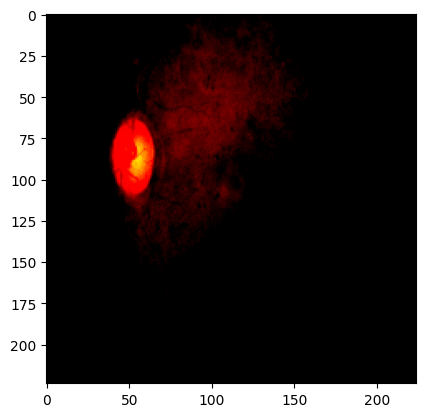

In [ ]:
plt.imshow(rds_train[0][0].permute(1, 2, 0))

In [ ]:
train_idx, valid_idx = train_test_split(np.arange(len(rds_train)), shuffle=False,
                                                    test_size=0.3, random_state=42)

In [ ]:
train_subset = Subset(rds_train, train_idx)
valid_subset = Subset(rds_val, valid_idx)

train_loader = DataLoader(train_subset, batch_size=8,
                          shuffle=True, num_workers=0)

valid_loader = DataLoader(valid_subset, batch_size=8,
                          shuffle=True, num_workers=0)

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels: int=3, patch_size: int=16,
                 emb_size: int=768, img_size: int=224):
        self.patch_size = patch_size
        super().__init__()
        self.projection = nn.Sequential(
            # using a conv layer instead of a linear one -> performance gains
            nn.Conv2d(in_channels, emb_size,
                      kernel_size=patch_size, stride=patch_size),
            Rearrange('b e (h) (w) -> b (h w) e'),
        )
        self.cls_token = nn.Parameter(torch.randn(1,1, emb_size))
        self.positions = nn.Parameter(
                         torch.randn((img_size // patch_size) **2 + 1, emb_size))


    def forward(self, x: Tensor) -> Tensor:
        b, _, _, _ = x.shape
        x = self.projection(x)
        cls_tokens = repeat(self.cls_token, '() n e -> b n e', b=b)
        # prepend the cls token to the input
        x = torch.cat([cls_tokens, x], dim=1)
        # add position embedding
        x += self.positions
        return x

class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size: int=768, num_heads: int=8, dropout: float=0):
        super().__init__()
        self.emb_size = emb_size
        self.num_heads = num_heads
        # fuse the queries, keys and values in one matrix
        self.qkv = nn.Linear(emb_size, emb_size * 3)
        self.att_drop = nn.Dropout(dropout)
        self.projection = nn.Linear(emb_size, emb_size)

    def forward(self, x : Tensor, mask: Tensor = None) -> Tensor:
        # split keys, queries and values in num_heads
        qkv = rearrange(self.qkv(x),
                        "b n (h d qkv) -> (qkv) b h n d", h=self.num_heads, qkv=3)
        queries, keys, values = qkv[0], qkv[1], qkv[2]
        # sum up over the last axis
        # batch, num_heads, query_len, key_len
        energy = torch.einsum('bhqd, bhkd -> bhqk', queries, keys)
        if mask is not None:
            fill_value = torch.finfo(torch.float32).min
            energy.mask_fill(~mask, fill_value)

        scaling = self.emb_size ** (1/2)
        att = F.softmax(energy, dim=-1) / scaling
        att = self.att_drop(att)
        # sum up over the third axis
        out = torch.einsum('bhal, bhlv -> bhav ', att, values)
        out = rearrange(out, "b h n d -> b n (h d)")
        out = self.projection(out)
        return out

class ResidualAdd(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        res = x
        x = self.fn(x, **kwargs)
        x += res
        return x

class FeedForwardBlock(nn.Sequential):
    def __init__(self, emb_size: int, expansion: int=4, drop_p: float=0.):
        super().__init__(
            nn.Linear(emb_size, expansion * emb_size),
            nn.GELU(),
            nn.Dropout(drop_p),
            nn.Linear(expansion * emb_size, emb_size),
        )

class TransformerEncoderBlock(nn.Sequential):
    def __init__(self,
                 emb_size: int = 768,
                 drop_p: float = 0.,
                 forward_expansion: int = 4,
                 forward_drop_p: float = 0.,
                 ** kwargs):
        super().__init__(
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                MultiHeadAttention(emb_size, **kwargs),
                nn.Dropout(drop_p)
            )),
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                FeedForwardBlock(
                    emb_size, expansion=forward_expansion, drop_p=forward_drop_p),
                nn.Dropout(drop_p)
            )
            ))

class TransformerEncoder(nn.Sequential):
    def __init__(self, depth: int=12, **kwargs):
        super().__init__(*[TransformerEncoderBlock(**kwargs) for _ in range(depth)])

class ClassificationHead(nn.Sequential):
    def __init__(self, emb_size: int=768, n_classes: int=1000):
        super().__init__(
            Reduce('b n e -> b e', reduction='mean'),
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, n_classes))

class ViT(nn.Sequential):
    def __init__(self,
                in_channels: int = 3,
                patch_size: int = 16,
                emb_size: int = 768,
                img_size: int = 224,
                depth: int = 12,
                n_classes: int = 5,
                **kwargs):
        super().__init__(
            PatchEmbedding(in_channels, patch_size, emb_size, img_size),
            TransformerEncoder(depth, emb_size=emb_size, **kwargs),
            ClassificationHead(emb_size, n_classes)
        )



In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=5, dropout_rate=0.5):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [ ]:
from torchvision import models

def get_resnet18(num_classes=5):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

In [ ]:
def get_resnet50(num_classes=5):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

In [ ]:
def get_efficientnet(num_classes=5):
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

In [ ]:
models_dict = {
    "SimpleCNN": SimpleCNN(),
    "ResNet18": get_resnet18(),
    "ResNet50": get_resnet50(),
    "EfficientNet": get_efficientnet(),
    # "ViT": ViT()
}

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 87.3MB/s]


In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

epochs = 30
patience = 5
clip_value = 1.0
weight_decay = 1e-4
lr = 5e-5
mixup_alpha = 0.4
num_classes = 5

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils as utils

from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import models

In [ ]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=2e-5)
# scheduler = StepLR(optimizer, step_size=1, gamma=0.7)

In [ ]:
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam*x + (1-lam)*x[idx]
    return mixed_x, y, y[idx], lam

def mixup_loss(output, y_a, y_b, lam):
    return lam*criterion(output,y_a) + (1-lam)*criterion(output,y_b)

In [ ]:
def train_model(model_name, model):

    print(f"\n========== TRAINING {model_name} ==========\n")

    model = model.to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler()

    best_val_acc = 0
    early_stop = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    save_path = f"{model_name}.pth"
    for epoch in range(epochs):

        # ================= TRAIN =================

        model.train()

        train_loss = 0
        train_acc = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            x_mix, y_a, y_b, lam = mixup_data(x, y, mixup_alpha)
            optimizer.zero_grad()
            with autocast():
                out = model(x_mix)
                loss = mixup_loss(out, y_a, y_b, lam)
            scaler.scale(loss).backward()
            utils.clip_grad_norm_(model.parameters(), clip_value)

            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_acc += (out.argmax(1) == y).float().mean().item()

        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        # ================= VALIDATION =================

        model.eval()

        val_loss = 0
        val_acc = 0

        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)

                with autocast():
                    out = model(x)
                    loss = criterion(out, y)
                val_loss += loss.item()
                val_acc += (out.argmax(1) == y).float().mean().item()

        val_loss /= len(valid_loader)
        val_acc /= len(valid_loader)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"TL {train_loss:.4f} | "
            f"TA {train_acc:.4f} | "
            f"VL {val_loss:.4f} | "
            f"VA {val_acc:.4f}"
        )

        # ================= SAVE BEST =================

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            early_stop = 0

        else:
            early_stop += 1

        if early_stop >= patience:
            print(f"Early stopping for {model_name}")
            break

    return history, best_val_acc, save_path

In [ ]:
results = {}

for name, model in models_dict.items():
    history, best_acc, path = train_model(name, model)
    results[name] = {
        "history": history,
        "best_acc": best_acc,
        "path": path
    }


========== TRAINING SimpleCNN ==========



/tmp/ipykernel_1591/1345025377.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_1591/1345025377.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1591/1345025377.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/30 | TL 1.5882 | TA 0.2629 | VL 1.4706 | VA 0.3434
Epoch 2/30 | TL 1.5292 | TA 0.3139 | VL 1.4203 | VA 0.3898
Epoch 3/30 | TL 1.4980 | TA 0.3193 | VL 1.3464 | VA 0.4225
Epoch 4/30 | TL 1.4595 | TA 0.3284 | VL 1.3040 | VA 0.4552
Epoch 5/30 | TL 1.4143 | TA 0.3542 | VL 1.2509 | VA 0.4583
Epoch 6/30 | TL 1.3621 | TA 0.3476 | VL 1.1767 | VA 0.5200
Epoch 7/30 | TL 1.3650 | TA 0.3607 | VL 1.2298 | VA 0.4705
Epoch 8/30 | TL 1.3512 | TA 0.3691 | VL 1.1364 | VA 0.5427
Epoch 9/30 | TL 1.3377 | TA 0.3816 | VL 1.1776 | VA 0.5222
Epoch 10/30 | TL 1.3437 | TA 0.3832 | VL 1.1118 | VA 0.5390
Epoch 11/30 | TL 1.3374 | TA 0.3775 | VL 1.1130 | VA 0.5380
Epoch 12/30 | TL 1.3133 | TA 0.3598 | VL 1.1371 | VA 0.5454
Epoch 13/30 | TL 1.2966 | TA 0.3687 | VL 1.1263 | VA 0.5369
Epoch 14/30 | TL 1.3155 | TA 0.4060 | VL 1.1156 | VA 0.5533
Epoch 15/30 | TL 1.2990 | TA 0.3802 | VL 1.1080 | VA 0.5638
Epoch 16/30 | TL 1.2943 | TA 0.3718 | VL 1.1087 | VA 0.5549
Epoch 17/30 | TL 1.3000 | TA 0.3770 | VL 1.0977 |

/tmp/ipykernel_1591/1345025377.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 9/30 | TL 0.8402 | TA 0.5500 | VL 0.5420 | VA 0.8196


...

Epoch 10/30 | TL 0.8111 | TA 0.5281 | VL 0.4898 | VA 0.8402
Epoch 11/30 | TL 0.7552 | TA 0.5634 | VL 0.4544 | VA 0.8481
Epoch 12/30 | TL 0.7098 | TA 0.5842 | VL 0.4071 | VA 0.8761
Epoch 13/30 | TL 0.7108 | TA 0.6135 | VL 0.3971 | VA 0.8713
Epoch 14/30 | TL 0.6585 | TA 0.5870 | VL 0.3659 | VA 0.8887
Epoch 15/30 | TL 0.6009 | TA 0.5761 | VL 0.3541 | VA 0.8808
Epoch 16/30 | TL 0.6069 | TA 0.6046 | VL 0.3656 | VA 0.8829
Epoch 17/30 | TL 0.5941 | TA 0.6030 | VL 0.3455 | VA 0.8840
Epoch 18/30 | TL 0.5427 | TA 0.6332 | VL 0.3630 | VA 0.8840
Epoch 19/30 | TL 0.5714 | TA 0.6433 | VL 0.3380 | VA 0.8877
Early stopping for ResNet50

========== TRAINING EfficientNet ==========



/tmp/ipykernel_1591/1345025377.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/30 | TL 1.4734 | TA 0.3096 | VL 1.2708 | VA 0.5338
Epoch 2/30 | TL 1.2772 | TA 0.4033 | VL 1.0766 | VA 0.6482
Epoch 3/30 | TL 1.1829 | TA 0.4121 | VL 0.9846 | VA 0.6456
Epoch 4/30 | TL 1.1211 | TA 0.4246 | VL 0.8520 | VA 0.6857
Epoch 5/30 | TL 1.0558 | TA 0.4751 | VL 0.7810 | VA 0.7173
Epoch 6/30 | TL 1.0433 | TA 0.4710 | VL 0.7435 | VA 0.7136
Epoch 7/30 | TL 1.0248 | TA 0.4733 | VL 0.6967 | VA 0.7347
Epoch 8/30 | TL 1.0084 | TA 0.4964 | VL 0.6622 | VA 0.7484
Epoch 9/30 | TL 0.9625 | TA 0.5057 | VL 0.6529 | VA 0.7426
Epoch 10/30 | TL 0.9687 | TA 0.4728 | VL 0.5826 | VA 0.7832
Epoch 11/30 | TL 0.8886 | TA 0.4952 | VL 0.5509 | VA 0.8080
Epoch 12/30 | TL 0.8845 | TA 0.5061 | VL 0.5183 | VA 0.8143
Epoch 13/30 | TL 0.8320 | TA 0.5430 | VL 0.4905 | VA 0.8291
Epoch 14/30 | TL 0.8826 | TA 0.5165 | VL 0.4916 | VA 0.8233
Epoch 15/30 | TL 0.8167 | TA 0.4959 | VL 0.4912 | VA 0.8270
Epoch 16/30 | TL 0.8089 | TA 0.5446 | VL 0.4446 | VA 0.8513
Epoch 17/30 | TL 0.7617 | TA 0.5555 | VL 0.5213 |

/tmp/ipykernel_1591/1345025377.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1591/1345025377.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1591/1345025377.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 18/30 | TL 0.7889 | TA 0.5697 | VL 0.4522 | VA 0.8354
Epoch 19/30 | TL 0.7707 | TA 0.5793 | VL 0.4558 | VA 0.8539
Epoch 20/30 | TL 0.7429 | TA 0.5525 | VL 0.4586 | VA 0.8402
Epoch 21/30 | TL 0.7352 | TA 0.5686 | VL 0.4171 | VA 0.8650
Epoch 22/30 | TL 0.7463 | TA 0.5507 | VL 0.4259 | VA 0.8544
Epoch 23/30 | TL 0.7386 | TA 0.5761 | VL 0.4164 | VA 0.8608
Epoch 24/30 | TL 0.7238 | TA 0.5673 | VL 0.4632 | VA 0.8481
Epoch 25/30 | TL 0.7454 | TA 0.5505 | VL 0.4595 | VA 0.8465
Epoch 26/30 | TL 0.7662 | TA 0.5811 | VL 0.4208 | VA 0.8623
Early stopping for EfficientNet


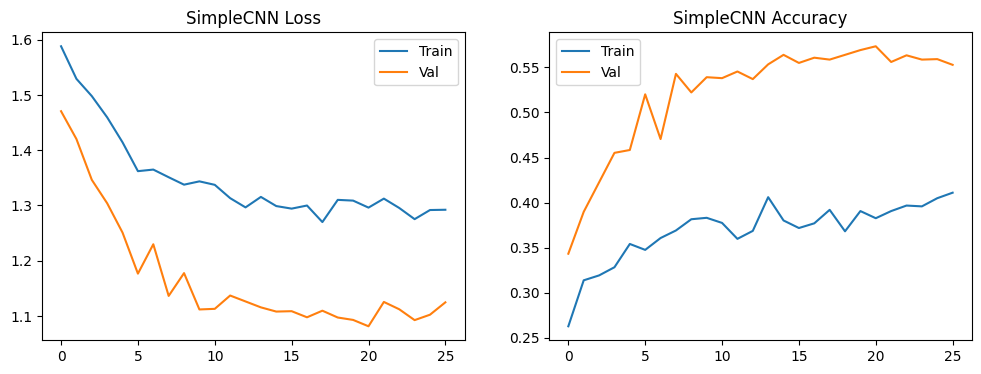

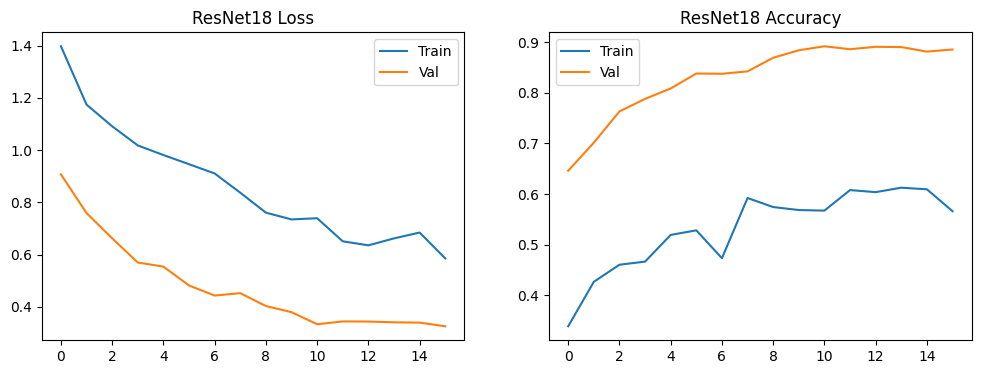

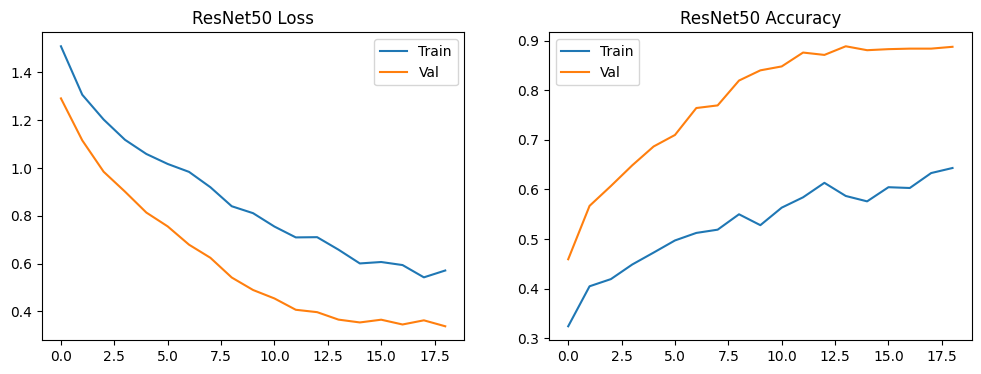

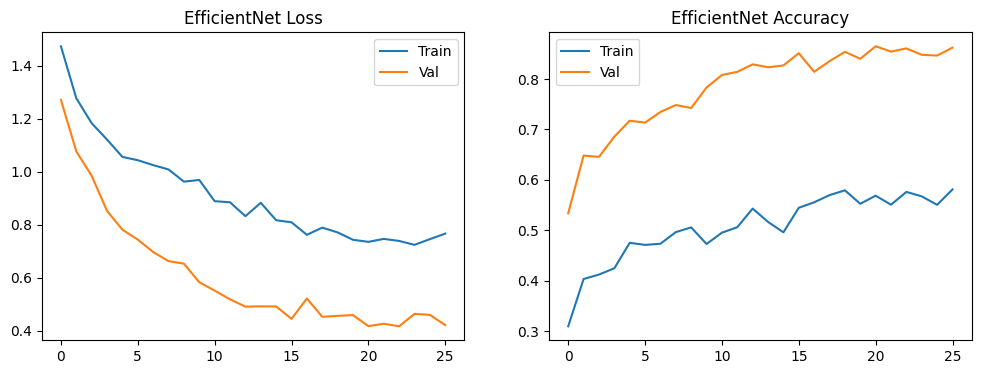

In [ ]:
for name, result in results.items():
    h = result["history"]
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)

    plt.plot(h["train_loss"], label="Train")
    plt.plot(h["val_loss"], label="Val")

    plt.title(f"{name} Loss")
    plt.legend()

    plt.subplot(1,2,2)

    plt.plot(h["train_acc"], label="Train")
    plt.plot(h["val_acc"], label="Val")

    plt.title(f"{name} Accuracy")
    plt.legend()

    plt.show()

In [ ]:
sorted_models = sorted(
    results.items(),
    key=lambda x: x[1]["best_acc"],
    reverse=True
)

print("\n========== TOP 2 MODELS ==========\n")

for i in range(2):
    name = sorted_models[i][0]
    acc = sorted_models[i][1]["best_acc"]
    path = sorted_models[i][1]["path"]

    print(f"{i+1}. {name}")
    print(f"Validation Accuracy : {acc:.4f}")
    print(f"Saved Model Path    : {path}\n")


========== TOP 2 MODELS ==========

1. ResNet18
Validation Accuracy : 0.8919
Saved Model Path    : ResNet18.pth

2. ResNet50
Validation Accuracy : 0.8887
Saved Model Path    : ResNet50.pth



In [ ]:
torch.save(model.state_dict(), "ResNet18.pth")
torch.save(model.state_dict(), "ResNet50.pth")

from google.colab import files

files.download("ResNet18.pth")
files.download("")

In [ ]:
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.nn.utils as utils
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns
# from torch.optim.lr_scheduler import CosineAnnealingLR
# from torch.optim import AdamW
# import time
# from torch.utils.data import DataLoader
# from torch.cuda.amp import GradScaler, autocast
# from torchvision import transforms

# # Data Augmentation
# train_transforms = transforms.Compose([
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),
#     transforms.ToTensor()
# ])

# # Hyperparameters
# epochs = 50
# patience = 10
# clip_value = 1.0
# weight_decay = 1e-4
# dropout_rate = 0.5
# mixup_alpha = 0.4
# batch_size = 16
# lr = 5e-5

# # Initialize model
# # model = YourModelClass(dropout_rate=dropout_rate)
# model = model.to(device)

# # Optimizer
# optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# # Mixed precision scaler
# scaler = GradScaler()

# # Learning rate scheduler
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

# # SWA model
# swa_model = torch.optim.swa_utils.AveragedModel(model)

# # Early stopping
# best_val_loss = float('inf')
# early_stopping_counter = 0

# # Storage
# train_loss_history = []
# train_acc_history = []
# val_loss_history = []
# val_acc_history = []

# # Weight initialization
# def init_weights(m):
#     if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
#         nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
#         if m.bias is not None:
#             nn.init.zeros_(m.bias)

# model.apply(init_weights)

# # Mixup augmentation
# def mixup_data(x, y, alpha=0.4):
#     if alpha > 0:
#         lam = np.random.beta(alpha, alpha)
#     else:
#         lam = 1
#     batch_size = x.size(0)
#     index = torch.randperm(batch_size).to(x.device)
#     mixed_x = lam * x + (1 - lam) * x[index, :]
#     y_a, y_b = y, y[index]
#     return mixed_x, y_a, y_b, lam

# def mixup_criterion(criterion, output, y_a, y_b, lam):
#     return lam * criterion(output, y_a) + (1 - lam) * criterion(output, y_b)

# # Label smoothing
# def label_smooth_loss(output, target, epsilon=0.1):
#     n_classes = output.size(1)
#     one_hot = torch.zeros_like(output).scatter(1, target.unsqueeze(1), 1)
#     smoothed_labels = (1 - epsilon) * one_hot + epsilon / n_classes
#     return (-smoothed_labels * F.log_softmax(output, dim=1)).sum(dim=1).mean()

# # Training loop
# start_time = time.time()

# for epoch in range(epochs):
#     model.train()
#     epoch_train_loss = 0.0
#     epoch_train_acc = 0.0

#     for i, (data, label) in enumerate(train_loader):
#         data, label = data.to(device), label.to(device)

#         # Mixup
#         mixed_data, targets_a, targets_b, lam = mixup_data(data, label, alpha=mixup_alpha)

#         optimizer.zero_grad()

#         with autocast():
#             output = model(mixed_data)

#             # Label smoothing & mixup
#             smooth_factor = 0.1 if epoch < 30 else 0.05
#             loss = mixup_criterion(
#                 lambda o, t: label_smooth_loss(o, t, epsilon=smooth_factor),
#                 output, targets_a, targets_b, lam
#             )

#         # Gradient scaling
#         scaler.scale(loss).backward()

#         # Gradient clipping
#         utils.clip_grad_norm_(model.parameters(), clip_value)
#         scaler.step(optimizer)
#         scaler.update()

#         acc = (output.argmax(dim=1) == label).float().mean().item()
#         epoch_train_loss += loss.item()
#         epoch_train_acc += acc

#     # Average metrics
#     epoch_train_loss /= len(train_loader)
#     epoch_train_acc /= len(train_loader)

#     # Validation
#     model.eval()
#     epoch_val_loss = 0.0
#     epoch_val_acc = 0.0
#     true_labels = []
#     predicted_labels = []

#     with torch.no_grad():
#         for data, label in valid_loader:
#             data, label = data.to(device), label.to(device)

#             with autocast():
#                 val_output = model(data)
#                 val_loss = criterion(val_output, label)

#             acc = (val_output.argmax(dim=1) == label).float().mean().item()
#             epoch_val_loss += val_loss.item()
#             epoch_val_acc += acc

#             true_labels.extend(label.cpu().numpy())
#             predicted_labels.extend(val_output.argmax(dim=1).cpu().numpy())

#     epoch_val_loss /= len(valid_loader)
#     epoch_val_acc /= len(valid_loader)

#     # Store history
#     train_loss_history.append(epoch_train_loss)
#     train_acc_history.append(epoch_train_acc)
#     val_loss_history.append(epoch_val_loss)
#     val_acc_history.append(epoch_val_acc)

#     # Scheduler step
#     scheduler.step()

#     # Early stopping
#     if epoch_val_loss < best_val_loss:
#         best_val_loss = epoch_val_loss
#         early_stopping_counter = 0

#         # Update SWA model
#         swa_model.update_parameters(model)

#         torch.save({
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'epoch': epoch,
#             'best_val_loss': best_val_loss,
#         }, 'best_model.pth')
#     else:
#         early_stopping_counter += 1

#     if early_stopping_counter >= patience:
#         print(f"Early stopping at epoch {epoch + 1}")
#         break

#     # Print results
#     current_lr = optimizer.param_groups[0]['lr']
#     print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, "
#           f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}, LR: {current_lr:.2e}")

# # Apply SWA
# torch.optim.swa_utils.update_bn(train_loader, swa_model)

# # Training completion
# end_time = time.time()
# print(f"Training completed in {(end_time - start_time) / 60:.2f} minutes")

# # Load best model
# checkpoint = torch.load('best_model.pth')
# model.load_state_dict(checkpoint['model_state_dict'])

# # Plot training curves
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(train_loss_history, label='Train Loss')
# plt.plot(val_loss_history, label='Val Loss')
# plt.title('Loss Curve')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(train_acc_history, label='Train Acc')
# plt.plot(val_acc_history, label='Val Acc')
# plt.title('Accuracy Curve')
# plt.legend()
# plt.show()


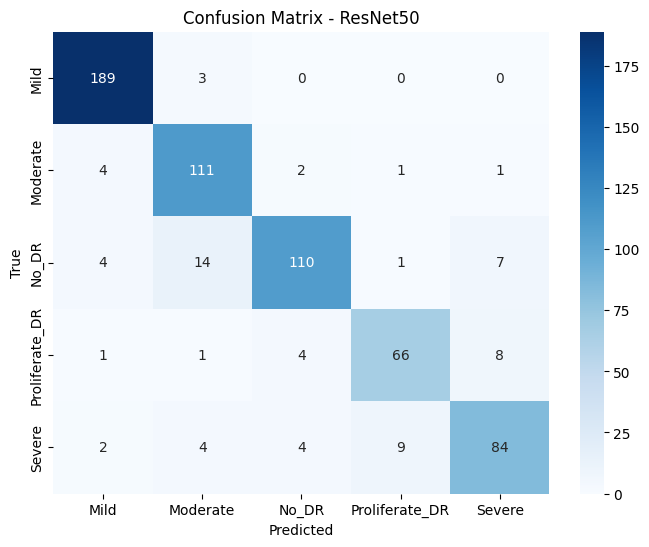

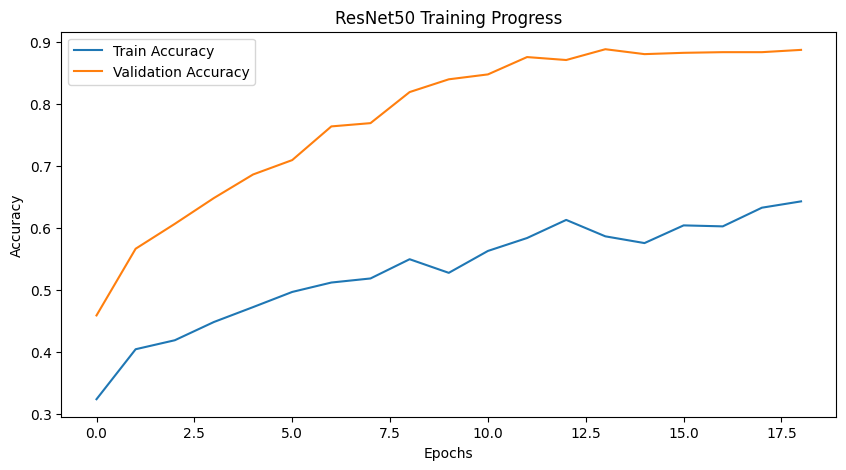

Extracting features for t-SNE...


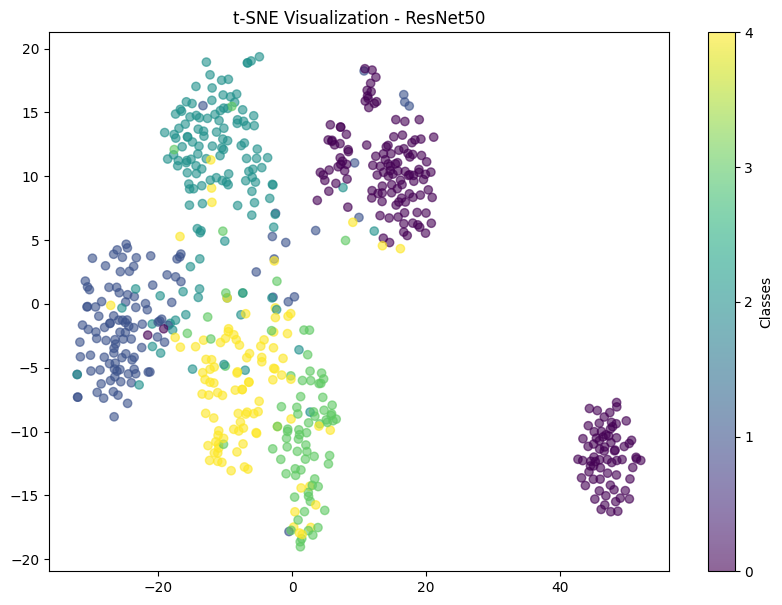

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import seaborn as sns

# Select the model to visualize
model_name = "ResNet50"
model = models_dict[model_name]
model.load_state_dict(torch.load(results[model_name]["path"]))
model = model.to(device)

history = results[model_name]["history"]
class_names = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

# Helper to get predictions
def get_predictions(loader, model):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, predicted_labels = get_predictions(valid_loader, model)

# 1. Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {model_name}')
plt.show()

# 2. Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'{model_name} Training Progress')
plt.legend()
plt.show()

# 3. t-SNE Plot
def extract_features(loader, model):
    # Using the layer before the classifier for features
    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
    feature_extractor.eval()
    features = []
    labels = []
    with torch.no_grad():
        for data, label in loader:
            data = data.to(device)
            output = feature_extractor(data)
            features.extend(output.view(output.size(0), -1).cpu().numpy())
            labels.extend(label.cpu().numpy())
    return np.array(features), np.array(labels)

print("Extracting features for t-SNE...")
val_features, val_labels = extract_features(valid_loader, model)
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(val_features)

plt.figure(figsize=(10, 7))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=val_labels, cmap='viridis', alpha=0.6)
plt.colorbar(ticks=range(5), label='Classes')
plt.title(f't-SNE Visualization - {model_name}')
plt.show()

In [ ]:
# Move model to CPU before saving
model.cpu()

# Save the model
torch.save(model, "model.pth")

print("✅ Model saved successfully as 'model.pth'")


✅ Model saved successfully as 'model.pth'


In [ ]:
torch.save(model.state_dict(), "ResNet18.pth")
torch.save(model.state_dict(), "ResNet50.pth")

from google.colab import files

files.download("ResNet18.pth")
files.download("ResNet50.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>